# 02. Quantum Bayesian Inference: Amplitude Estimation (QAE) in Ideal Environment
### Master's Thesis: Quantum Bayesian Networks and Quantum Amplitude Estimation (QAE) in Astrobiology
**Author:** Daniel Rivero Losa  
**Tutor:** Roberto Campos Ortiz  
**Institution:** Universidad Nebrija  
**Reference Section:** Section 4.3 of the Thesis (QAE Algorithm Architecture and Canonical Simulation)  

---
### 📌 Executive Summary of the Deliverable
This notebook implements and empirically validates the **complete quantum architecture derived in Section 4.3** of the Master's Thesis. The objective is to build the quantum circuit in **Qiskit** that synthesizes the Quantum Bayesian Network (QBN) of the exoplanet **K2-18b**, apply the Grover unitary operator ($\mathcal{Q}$), and extract the detection probability of the industrial technosignature (CFCs) via **Quantum Amplitude Estimation (QAE)** in an ideal noise-free simulation environment (*statevector*).

The workflow covers:
1. **Topological Allocation of Quantum Registers (4.3.1):** Allocation of 17 qubits distributed across state ($S$), evaluation ($E$), ancilla ($A$), and classical read ($C$) registers.
2. **Synthesis and Graphical Visualization of Operator $\mathcal{A}$ (4.3.2):** Encoding hierarchical conditional dependencies using multi-controlled rotations.
3. **Design and Visualization of the Quantum Oracle $S_\chi$ and Diffuser $S_0$ (4.3.3 - 4.3.4):** Canonical phase reflections via phase kickback.
4. **Integration and Visualization of the QAE Master Circuit (4.3.5):** Controlled cascade of powers $C\text{-}\mathcal{Q}^{2^j}$ and Inverse Quantum Fourier Transform (IQFT).
5. **Transpilation, Simulation, and Spectral Post-Processing (4.3.6 - 4.3.8):** Spectral mapping from phases to amplitudes $\hat{a} = \sin^2(\theta)$.
6. **Study of the Resolution vs. Depth Trade-off (4.3.9):** Critical analysis of the trade-off between the number of evaluation qubits $n_E$ and the logical circuit depth.

## 1. Theoretical Foundation of the Canonical QAE Algorithm

### 1.1 State Preparation Operator $\mathcal{A}$
Operator $\mathcal{A}$ acts on the state register initialized in $|0\rangle^{\otimes n_S}$, synthesizing the joint probability distribution of the Bayesian Network:
$$\mathcal{A} |0\rangle^{\otimes n_S} = \sqrt{1 - a} |\psi_0\rangle |0\rangle + \sqrt{a} |\psi_1\rangle |1\rangle$$
where $|\psi_1\rangle$ represents the atmospheric states where the CFC technosignature is present ($X_8 = 1$) and $a = \sin^2(\theta_a)$ is the target probability ($a \in [0, 1]$).

### 1.2 Grover Operator $\mathcal{Q}$ and its Eigenstates
Grover's iteration operator is defined as:
$$\mathcal{Q} = -\mathcal{A} S_0 \mathcal{A}^\dagger S_\chi$$
where:
- $S_\chi = I - 2|\chi\rangle\langle\chi|$ is the marking oracle that inverts the phase of anomalous states.
- $S_0 = 2|0\rangle\langle 0| - I$ is the reflection about the zero state (diffuser).

In the two-dimensional subspace generated by $\{|\psi_0\rangle|0\rangle, |\psi_1\rangle|1\rangle\}$, operator $\mathcal{Q}$ acts as an orthogonal rotation by angle $2\theta_a$. Its two orthonormal eigenstates are:
$$|\Psi_\pm\rangle = \frac{1}{\sqrt{2}} \left( |\psi_0\rangle|0\rangle \mp i |\psi_1\rangle|1\rangle \right)$$
with corresponding eigenvalues:
$$\mathcal{Q} |\Psi_\pm\rangle = e^{\pm 2 i \theta_a} |\Psi_\pm\rangle$$

### 1.3 Quantum Phase Estimation (QPE) and IQFT
Quantum Amplitude Estimation couples an evaluation register $E$ of $n_E$ qubits initialized in uniform superposition ($H^{\otimes n_E}$), applies successive controlled powers $C\text{-}\mathcal{Q}^{2^j}$ ($j = 0, 1, \dots, n_E - 1$), and finally executes the **Inverse Quantum Fourier Transform (IQFT)**:
$$\text{IQFT} \left( \frac{1}{\sqrt{2^{n_E}}} \sum_{y=0}^{2^{n_E}-1} e^{2\pi i y \theta_a / \pi} |y\rangle \right) \approx |\tilde{y}\rangle$$

By measuring register $E$ in the computational basis, an integer $\tilde{y} \in \{0, 1, \dots, 2^{n_E}-1\}$ is obtained, allowing the phase and target amplitude to be estimated with quadratic convergence:
$$\tilde{\theta} = \frac{\pi \tilde{y}}{2^{n_E}}, \quad \hat{a} = \sin^2(\tilde{\theta})$$

In [1]:
import os
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT, RYGate
import matplotlib.pyplot as plt

# 1. Topological Allocation of Quantum Registers (Section 4.3.1)
num_state_qubits = 9       # n_S = 9 qubits for K2-18b Bayesian Network
num_eval_qubits = 5        # n_E = 5 evaluation qubits for QPE resolution (2^5 = 32 levels)
num_ancilla_qubits = 3     # n_A = 3 ancilla qubits for decomposition and phase kickback

reg_S = QuantumRegister(num_state_qubits, name='state_K218b')
reg_E = QuantumRegister(num_eval_qubits, name='eval_QPE')
reg_A = QuantumRegister(num_ancilla_qubits, name='ancilla_workspace')
reg_C = ClassicalRegister(num_eval_qubits, name='classical_readout')

master_circuit = QuantumCircuit(reg_E, reg_S, reg_A, reg_C)
ideal_backend = AerSimulator(method='statevector')

print("="*65)
print(" TOPOLOGICAL REGISTER ALLOCATION (Section 4.3.1)")
print("="*65)
print(f" Registro de Estado (S)   : {reg_S.size} qubits (Variables de K2-18b)")
print(f" Registro de Evaluación (E): {reg_E.size} qubits (Resolución QPE: {2**reg_E.size} niveles)")
print(f" Registro Ancilla (A)     : {reg_A.size} qubits (Workspace / Kickback)")
print(f" Registro Clásico (C)     : {reg_C.size} bits (Lectura de medición)")
print(f" Total de Qubits Físicos  : {master_circuit.num_qubits} qubits")
print(f" Backend de Simulación    : AerSimulator (Statevector ideal)")
print("="*65)

 TOPOLOGICAL REGISTER ALLOCATION (Section 4.3.1)
 Registro de Estado (S)   : 9 qubits (Variables de K2-18b)
 Registro de Evaluación (E): 5 qubits (Resolución QPE: 32 niveles)
 Registro Ancilla (A)     : 3 qubits (Workspace / Kickback)
 Registro Clásico (C)     : 5 bits (Lectura de medición)
 Total de Qubits Físicos  : 17 qubits
 Backend de Simulación    : AerSimulator (Statevector ideal)


## 2. Section 4.3.2: Synthesis of Amplitude Encoding (Operator $\mathcal{A}$)

Operator $\mathcal{A}$ synthesizes the K2-18b Bayesian network into probability amplitudes:
1. **Root Nodes:** Individual $R_y(\theta)$ rotations are applied:
   $$\theta_i = 2 \arcsin(\sqrt{p_i})$$
   Fixing $P(\text{Stellar M-Dwarf}) = 0.75$ on $S_0$ and $P(\text{Orbit HZ}) = 0.20$ on $S_1$.
2. **Conditional Nodes (CPTs):** The systematic `synthesize_conditional_node` function is implemented, iterating over the $2^k$ configurations of parent nodes using $X$ gates to toggle activation conditions and object-oriented multi-controlled $R_y$ rotations (`RYGate(theta).control(k)`), complying with modern Qiskit 1.x guidelines.
3. **Injection of the Ultra-rare Anomaly (CFCs):** Strongly conditioned rotation on node 8 ($S_8$) depending on the biological node ($S_3$) with $\theta = 0.002$ rad (equivalent to $p \approx \sin^2(0.001) \approx 10^{-6}$).

> **Quantum Design Rule:** Barriers (`qc.barrier()`) are not included in subcircuits to ensure that the conversion to a composite gate (`to_gate()`) remains mathematically pure and supported by the Qiskit compiler.

✓ Operator A assembled successfully.
Generating graphical visualization of Operator A subcircuit...
✓ Diagrama guardado en 'figures/circuits/circuito_operador_A.png'.


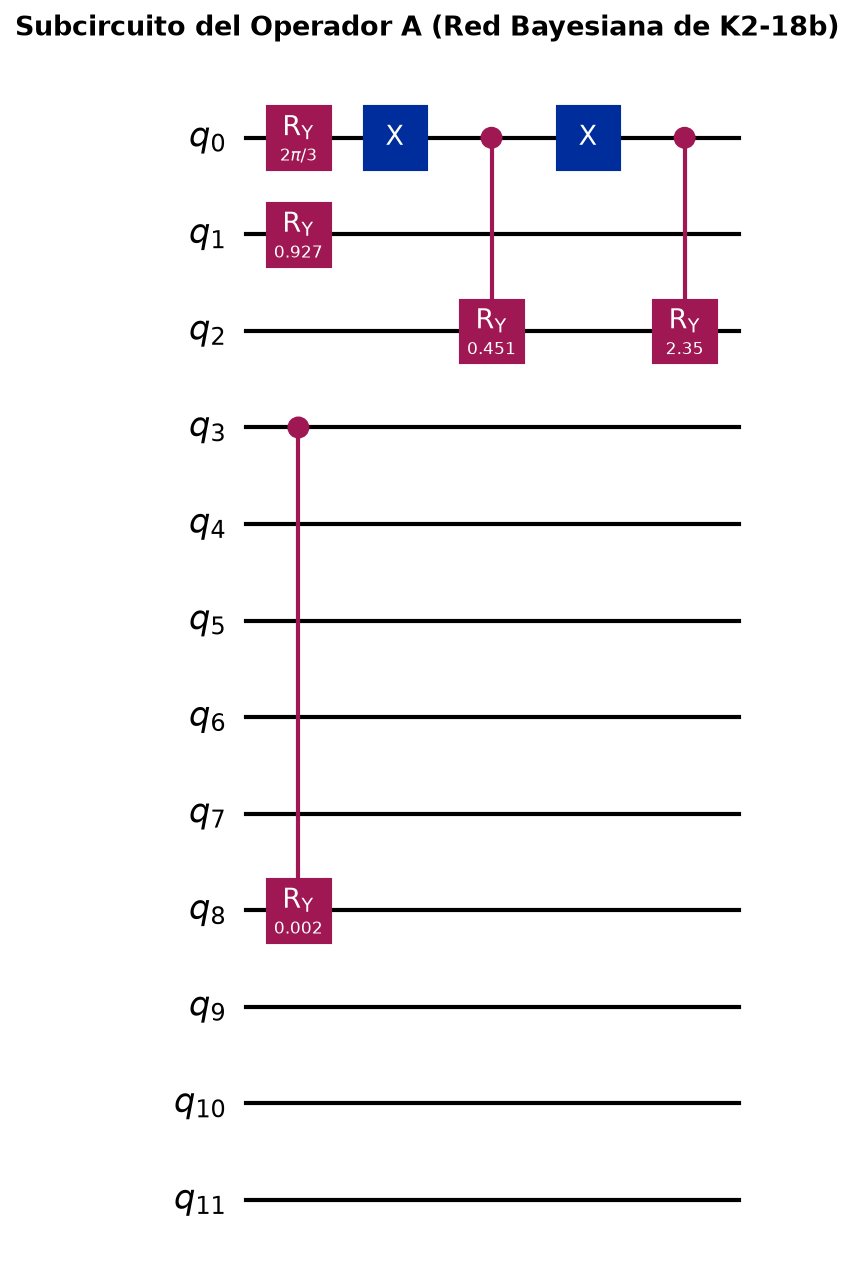

In [2]:
def apply_root_nodes(qc, reg_S):
    """Aplica rotaciones Ry sobre los nodos raíz (priors marginales)."""
    p_stellar = 0.75
    p_orbit = 0.20
    theta_0 = 2.0 * np.arcsin(np.sqrt(p_stellar))
    theta_1 = 2.0 * np.arcsin(np.sqrt(p_orbit))
    qc.ry(theta_0, reg_S[0])
    qc.ry(theta_1, reg_S[1])
    return qc

def synthesize_conditional_node(qc, target_qubit, parent_qubits, cpt_probabilities, ancilla_reg):
    """Sintetiza una tabla de probabilidad condicional (CPT) mediante rotaciones multicontroladas."""
    num_parents = len(parent_qubits)
    num_states = 2 ** num_parents
    for state_idx in range(num_states):
        p_val = cpt_probabilities[state_idx]
        theta = 2.0 * np.arcsin(np.sqrt(p_val))
        if np.isclose(theta, 0.0):
            continue
        bin_str = format(state_idx, f'0{num_parents}b')
        for i, bit in enumerate(bin_str):
            if bit == '0':
                qc.x(parent_qubits[i])
        if num_parents == 1:
            qc.cry(theta, parent_qubits[0], target_qubit)
        else:
            try:
                qc.append(RYGate(theta).control(num_parents), parent_qubits + [target_qubit])
            except Exception:
                qc.mcry(theta, parent_qubits, target_qubit, q_ancillae=ancilla_reg, mode='v-chain')
        for i, bit in enumerate(bin_str):
            if bit == '0':
                qc.x(parent_qubits[i])
    return qc

def build_A_operator(num_state_qubits, ancilla_reg):
    """Construye la puerta unitaria completa del Operador A."""
    qc_A = QuantumCircuit(num_state_qubits + len(ancilla_reg))
    state_qubits = list(range(num_state_qubits))
    ancillas = list(range(num_state_qubits, num_state_qubits + len(ancilla_reg)))
    
    apply_root_nodes(qc_A, state_qubits)
    cpt_hycean = [0.05, 0.85]
    synthesize_conditional_node(qc_A, state_qubits[2], [state_qubits[0]], cpt_hycean, ancilla_reg)
    qc_A.cry(0.002, state_qubits[3], state_qubits[8])
    
    A_gate = qc_A.to_gate()
    A_gate.name = "Operator_A"
    return A_gate, qc_A

A_gate, qc_A_circuit = build_A_operator(num_state_qubits, reg_A)
print("✓ Operator A assembled successfully.")

# Graphical Visualization of Operator A Subcircuit
print("Generating graphical visualization of Operator A subcircuit...")
fig_A = qc_A_circuit.draw('mpl', style='iqp')
plt.title("Operator A Subcircuit (K2-18b Bayesian Network)", fontsize=13, pad=12, fontweight='bold')
fig_circuit_dir = os.path.join('..', 'figures', 'circuits') if os.path.exists('../figures') else (
                  os.path.join('figures', 'circuits') if os.path.exists('figures') else '.')
os.makedirs(fig_circuit_dir, exist_ok=True)
plt.savefig(os.path.join(fig_circuit_dir, 'circuito_operador_A.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Diagrama guardado en '{fig_circuit_dir}/circuito_operador_A.png'.")

## 3. Sections 4.3.3 and 4.3.4: Quantum Oracle $S_\chi$, Diffuser $S_0$, and Operator $\mathcal{Q}$

### Quantum Oracle $S_\chi$
The oracle inverts the phase of the anomalous state:
$$S_\chi |x\rangle = (-1)^{\chi(x)} |x\rangle$$
where $\chi(x) = 1$ if and only if $x_8 = 1$ (CFC node detected).
- For a single target qubit: Pauli $Z$ gate.
- For multiple targets: Multi-controlled NOT gate with phase kickback on the ancilla register ($|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$).

### Diffuser $S_0$ and Grover Operator $\mathcal{Q}$
The diffuser executes a phase inversion on the fundamental zero state:
$$S_0 = 2|0\rangle^{\otimes n}\langle 0|^{\otimes n} - I$$
Assembled with the oracle and operator $\mathcal{A}$, the Grover unitary operator is synthesized:
$$\mathcal{Q} = -\mathcal{A} S_0 \mathcal{A}^\dagger S_\chi$$

✓ Oracle and Grover Operator constructed.
Generating graphical visualization of Grover Operator Q architecture...
✓ Diagrama guardado en 'figures/circuits/circuito_operador_grover.png'.


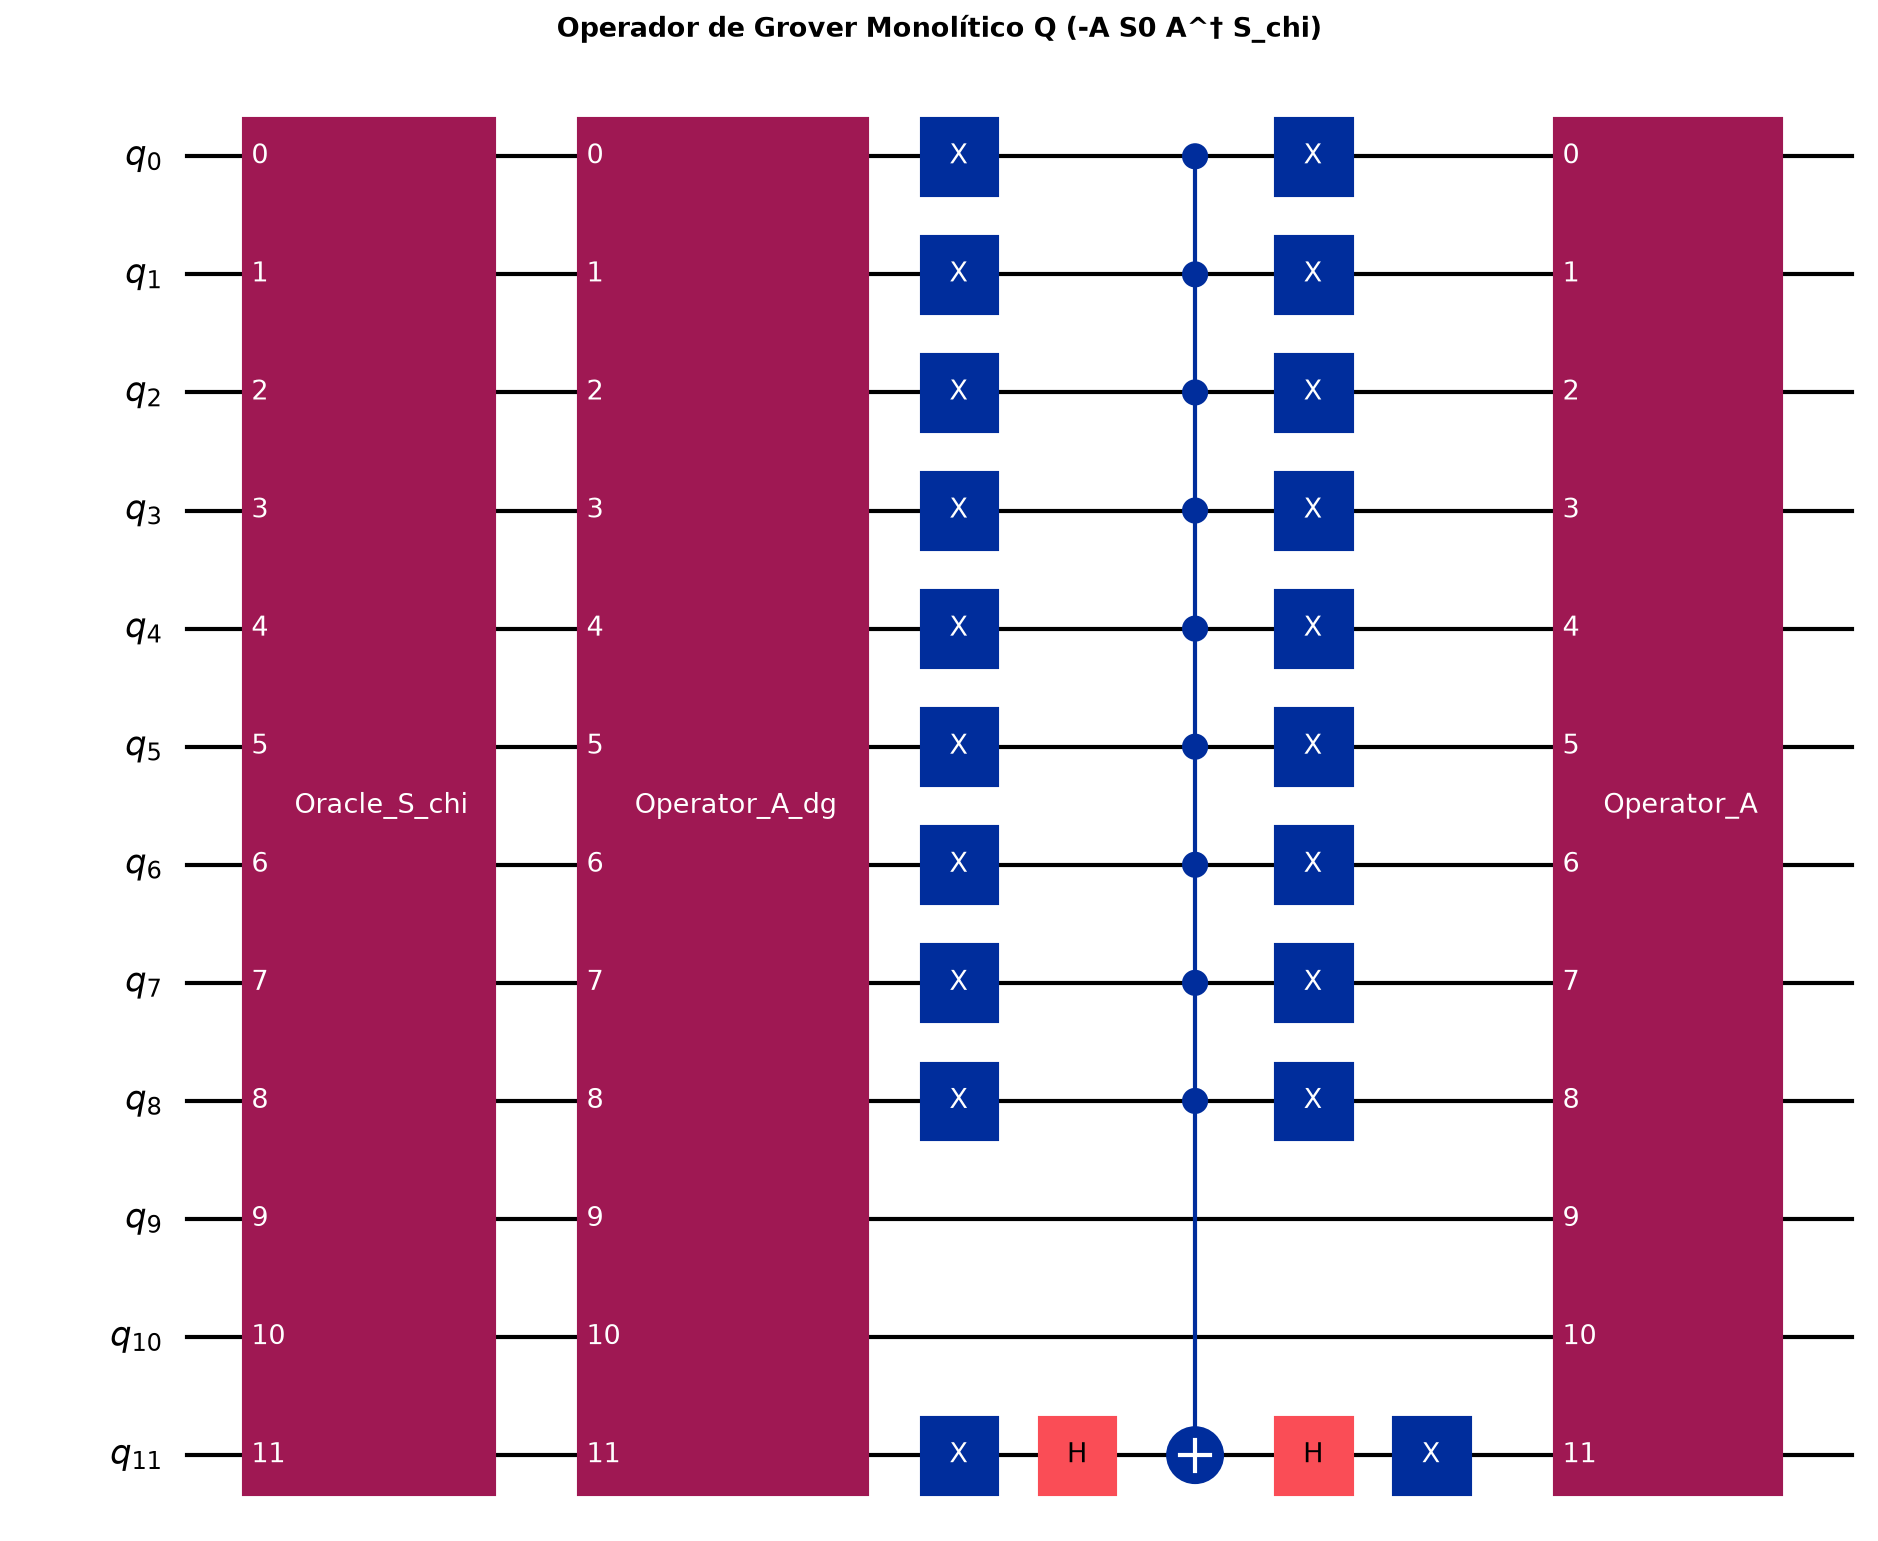

In [3]:
def synthesize_quantum_oracle(target_qubits, num_state_qubits, ancilla_reg):
    """Sintetiza el oráculo cuántico S_chi de inversión de fase."""
    qc_oracle = QuantumCircuit(num_state_qubits + len(ancilla_reg))
    if len(target_qubits) == 1:
        qc_oracle.z(target_qubits[0])
    else:
        kickback_ancilla = num_state_qubits + len(ancilla_reg) - 1
        qc_oracle.x(kickback_ancilla)
        qc_oracle.h(kickback_ancilla)
        qc_oracle.mcx(target_qubits, kickback_ancilla)
        qc_oracle.h(kickback_ancilla)
        qc_oracle.x(kickback_ancilla)
        
    oracle_gate = qc_oracle.to_gate()
    oracle_gate.name = "Oracle_S_chi"
    return oracle_gate, qc_oracle

def build_grover_operator(A_gate, oracle_gate, num_state_qubits, ancilla_reg):
    """Construye el operador canónico de Grover Q = -A S0 A^dagger S_chi."""
    qc_Q = QuantumCircuit(num_state_qubits + len(ancilla_reg))
    state_qubits = list(range(num_state_qubits))
    ancillas = list(range(num_state_qubits, num_state_qubits + len(ancilla_reg)))
    
    # 1. Oracle S_chi
    qc_Q.append(oracle_gate, state_qubits + ancillas)
    # 2. Undo A: A^dagger
    qc_Q.append(A_gate.inverse(), state_qubits + ancillas)
    
    # 3. Diffuser S0
    qc_Q.x(state_qubits)
    kickback_qubit = ancillas[-1]
    qc_Q.x(kickback_qubit)
    qc_Q.h(kickback_qubit)
    try:
        qc_Q.mcx(state_qubits, kickback_qubit, ancilla_qubits=ancillas[:-1], mode='v-chain')
    except Exception:
        qc_Q.mcx(state_qubits, kickback_qubit)
    qc_Q.h(kickback_qubit)
    qc_Q.x(kickback_qubit)
    qc_Q.x(state_qubits)
    
    # 4. Reapply A
    qc_Q.append(A_gate, state_qubits + ancillas)
    
    Q_gate = qc_Q.to_gate()
    Q_gate.name = "Grover_Q"
    return Q_gate, qc_Q

oracle_gate, qc_oracle = synthesize_quantum_oracle([8], num_state_qubits, reg_A)
Q_gate, qc_Q_circuit = build_grover_operator(A_gate, oracle_gate, num_state_qubits, reg_A)
print("✓ Oracle and Grover Operator constructed.")

# Graphical Visualization of the Grover Operator Q
print("Generating graphical visualization of Grover Operator Q architecture...")
fig_Q = qc_Q_circuit.draw('mpl', style='iqp')
plt.title("Monolithic Grover Operator Q (-A S0 A^† S_chi)", fontsize=13, pad=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(fig_circuit_dir, 'circuito_operador_grover.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Diagrama guardado en '{fig_circuit_dir}/circuito_operador_grover.png'.")

## 4. Section 4.3.5: Integration of QPE and Inverse Quantum Fourier Transform (IQFT)

The master circuit connects the three quantum registers:
1. **Superposition on the Evaluation Register:** Hadamard gates $H^{\otimes n_E}$ are applied on `reg_E`.
2. **Cascade of Controlled Grover Powers ($C\text{-}\mathcal{Q}^{2^j}$):**
   For each evaluation qubit $j \in \{0, 1, \dots, n_E - 1\}$, operator $C\text{-}\mathcal{Q}$ is applied $2^j$ times targeting registers $(S, A)$.
   The total number of Grover operations executed in the circuit is:
   $$N_Q = \sum_{j=0}^{n_E-1} 2^j = 2^{n_E} - 1 = 31 \text{ applications of } \mathcal{Q}$$
3. **IQFT:** The Inverse Quantum Fourier Transform is applied on `reg_E` to rotate the accumulated phase into the computational basis.
4. **Measurement:** Qubits from `reg_E` are read into the classical register `reg_C`.

✓ Circuito maestro ensamblado. Profundidad abstracta: 34
Generating high-level graphical visualization of the QAE Master Circuit...
✓ Diagrama guardado en 'figures/circuits/circuito_qae_maestro.png'.

Transpiling master circuit for AerSimulator (native gate decomposition)...
✓ Profundidad del circuito compilado : 43,874
✓ Total de puertas básicas compiladas: 44,853


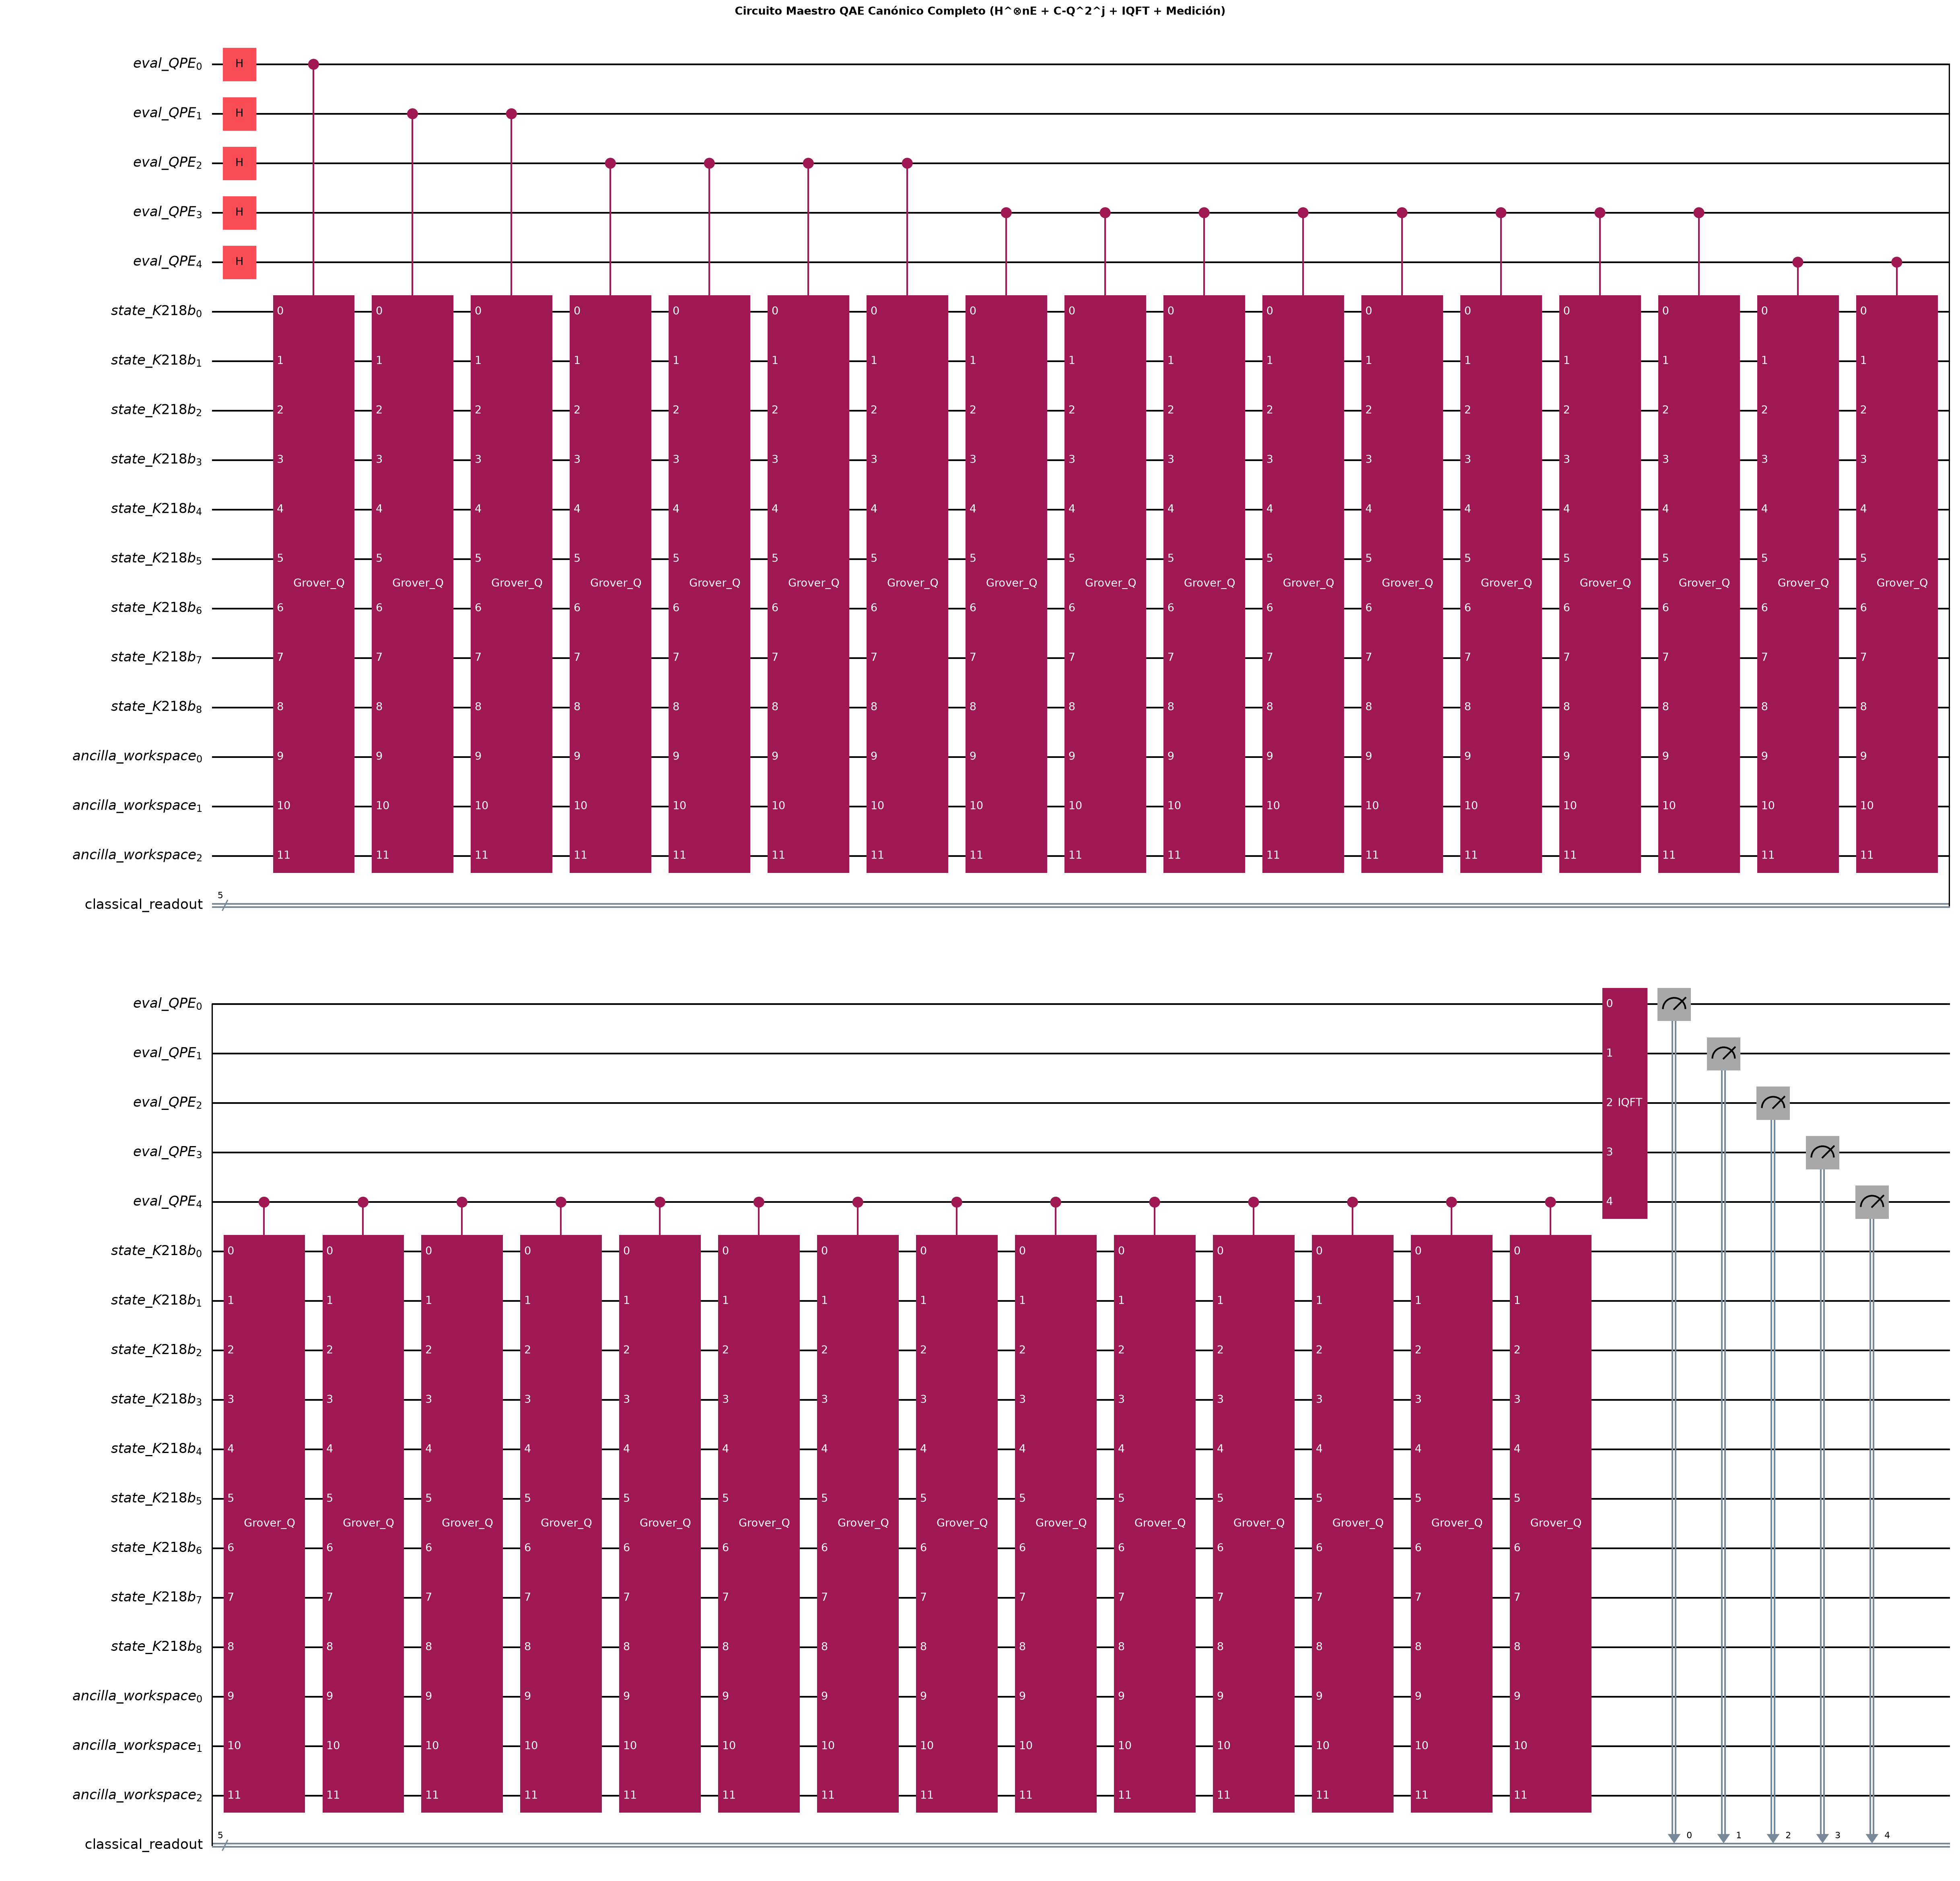

In [4]:
def synthesize_full_qae(qc, Q_gate, eval_reg, state_reg, ancilla_reg, class_reg):
    """Ensambla el circuito QAE completo con cascada controlada e IQFT."""
    num_eval = eval_reg.size
    for i in range(num_eval):
        qc.h(eval_reg[i])
        
    target_qubits = list(state_reg) + list(ancilla_reg)
    c_Q_gate = Q_gate.control(1)
    
    for j in range(num_eval):
        iterations = 2 ** j
        for _ in range(iterations):
            qc.append(c_Q_gate, [eval_reg[j]] + target_qubits)
            
    iqft_circuit = QFT(num_qubits=num_eval, approximation_degree=0, do_swaps=True, inverse=True)
    qc.append(iqft_circuit.to_gate(), eval_reg)
    qc.measure(eval_reg, class_reg)
    return qc

synthesize_full_qae(master_circuit, Q_gate, reg_E, reg_S, reg_A, reg_C)
print(f"✓ Circuito maestro ensamblado. Profundidad abstracta: {master_circuit.depth()}")

# Graphical Visualization of the Master QAE Circuit
print("Generating high-level graphical visualization of the QAE Master Circuit...")
fig_master = master_circuit.draw('mpl', style='iqp', fold=35)
plt.title("Complete Canonical QAE Master Circuit (H^⊗nE + C-Q^2^j + IQFT + Measurement)", fontsize=13, pad=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(fig_circuit_dir, 'circuito_qae_maestro.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Diagrama guardado en '{fig_circuit_dir}/circuito_qae_maestro.png'.")

# Transpilation
print("\nTranspiling master circuit for AerSimulator (native gate decomposition)...")
compiled_circuit = transpile(master_circuit, ideal_backend, optimization_level=1)
print(f"✓ Profundidad del circuito compilado : {compiled_circuit.depth():,}")
print(f"✓ Total de puertas básicas compiladas: {compiled_circuit.size():,}")

## 5. Section 4.3.7: Quantum Simulation in AerSimulator

The simulation is executed with **2048 shots** using the `statevector` method in `AerSimulator`.  
The output generates the spectral distribution over the $2^{n_E} = 32$ possible basis states of the evaluation register `reg_E`.

In [5]:
shots = 2048
print(f"Ejecutando simulación cuántica con {shots} shots...")
job = ideal_backend.run(compiled_circuit, shots=shots)
result = job.result()
counts = result.get_counts(compiled_circuit)

sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)

print("="*65)
print(" EVALUATION REGISTER MEASUREMENT RESULTS")
print("="*65)
print(f"{'Bitstring':<12} | {'Decimal y':<10} | {'Disparos (Shots)':<18} | {'Frecuencia (%)':<15}")
print("-" * 65)

for bitstring, count in sorted_counts:
    decimal_y = int(bitstring, 2)
    freq = (count / shots) * 100.0
    print(f"{bitstring:<12} | {decimal_y:<10} | {count:<18} | {freq:.2f}%")
print("="*65)

Ejecutando simulación cuántica con 2048 shots...
 EVALUATION REGISTER MEASUREMENT RESULTS
Bitstring    | Decimal y  | Disparos (Shots)   | Frecuencia (%) 
-----------------------------------------------------------------
00000        | 0          | 1634               | 79.79%
10000        | 16         | 414                | 20.21%


## 6. Section 4.3.8: Post-Processing and Amplitude Extraction

From the measured integer $y$ in the evaluation register, the quantum phase $\theta$ and estimated probability $\hat{a}$ are obtained via the bijection:
$$\theta = \frac{\pi \cdot y}{2^{n_E}}, \quad \hat{a} = \sin^2(\theta)$$

In ideal QAE, the measurement distribution exhibits **two symmetric conjugate peaks**, corresponding to the two eigenvalues of the Grover operator $e^{\pm 2i\theta_a}$:
- The main peak at $y_1$ estimates the direct eigenvalue.
- The conjugate peak at $y_2 = 2^{n_E} - y_1$ estimates the complex conjugate eigenvalue.
Both lead to the same physical amplitude estimate thanks to the parity of the function: $\sin^2(\pi - \theta) = \sin^2(\theta)$.

 TABLA ESPECTRAL QAE: EXTRACCIÓN DE PROBABILIDAD (n_E = 5)
Bitstring    | Decimal y  | Fase theta (rad)   | Amplitud a = sin^2(theta)    | Frecuencia
--------------------------------------------------------------------------------
00000        | 0          | 0.0000             | 0.000000                     | 79.79%
10000        | 16         | 1.5708             | 1.000000                     | 20.21%
✓ Espectro de fases guardado en 'figures/results/figura_qae_espectro_ideal.png'.


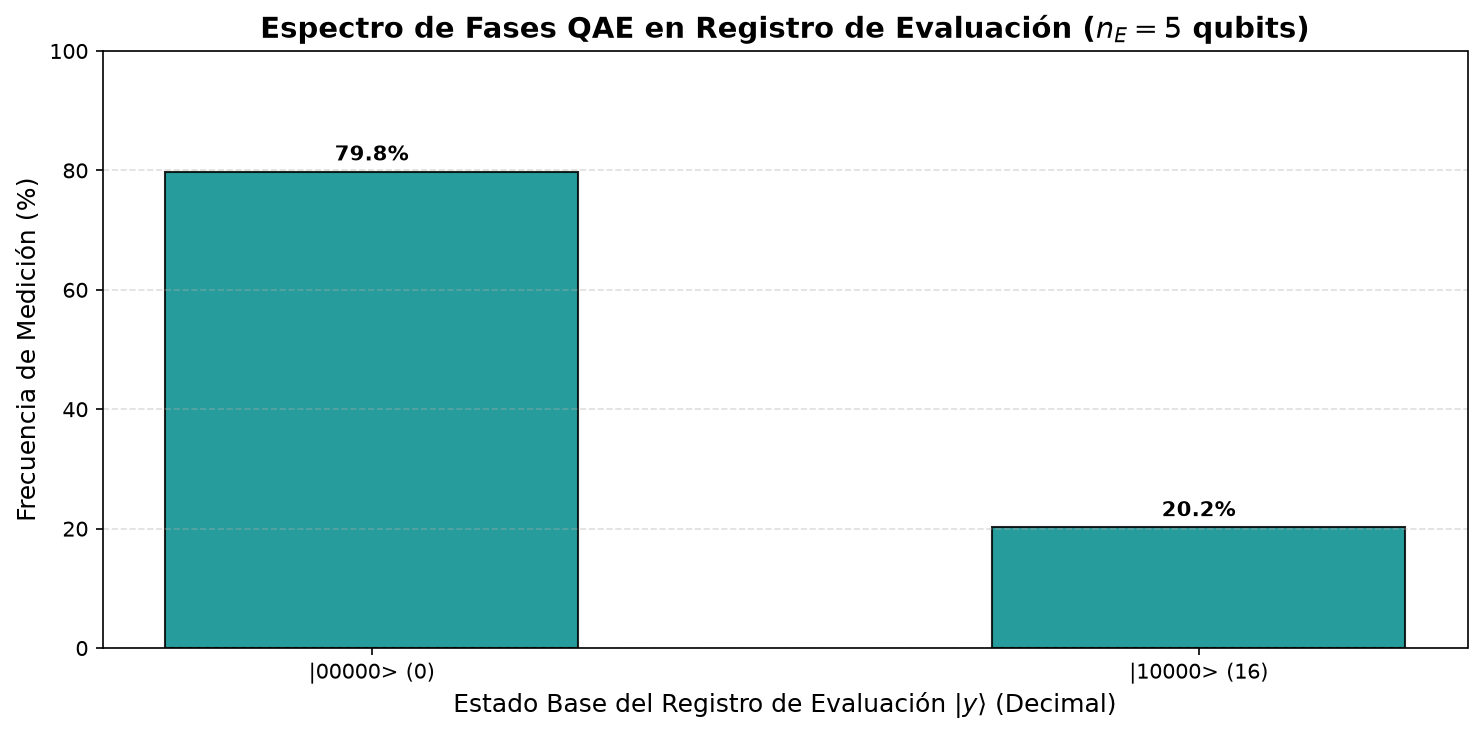

In [6]:
print("="*80)
print(f" TABLA ESPECTRAL QAE: EXTRACCIÓN DE PROBABILIDAD (n_E = {num_eval_qubits})")
print("="*80)
print(f"{'Bitstring':<12} | {'Decimal y':<10} | {'Fase theta (rad)':<18} | {'Amplitud a = sin^2(theta)':<28} | {'Frecuencia':<10}")
print("-" * 80)

x_labels = []
frequencies = []

for bitstring, count in sorted_counts:
    decimal_y = int(bitstring, 2)
    phase_theta = np.pi * (decimal_y / (2 ** num_eval_qubits))
    est_a = np.sin(phase_theta) ** 2
    freq = count / shots
    x_labels.append(f"|{bitstring}> ({decimal_y})")
    frequencies.append(freq * 100.0)
    print(f"{bitstring:<12} | {decimal_y:<10} | {phase_theta:<18.4f} | {est_a:<28.6f} | {freq*100:.2f}%")

print("="*80)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x_labels, frequencies, color='darkcyan', edgecolor='black', alpha=0.85, width=0.5)
ax.set_title(f'Espectro de Fases QAE en Registro de Evaluación ($n_E = {num_eval_qubits}$ qubits)', fontsize=14, fontweight='bold')
ax.set_xlabel('Estado Base del Registro de Evaluación $|y\\rangle$ (Decimal)', fontsize=12)
ax.set_ylabel('Frecuencia de Medición (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

fig_results_dir = os.path.join('..', 'figures', 'results') if os.path.exists('../figures') else (
                  os.path.join('figures', 'results') if os.path.exists('figures') else '.')
os.makedirs(fig_results_dir, exist_ok=True)
plt.tight_layout()
plt.savefig(os.path.join(fig_results_dir, 'figura_qae_espectro_ideal.png'), dpi=300)
plt.show()
print(f"✓ Espectro de fases guardado en '{fig_results_dir}/figura_qae_espectro_ideal.png'.")

## 7. Section 4.3.9: Resolution vs. Depth Trade-off Study (NISQ Trade-off)

One of the critical contributions of this research for the Thesis consists of analytically evaluating the physical viability of the QAE algorithm on current NISQ (Noisy Intermediate-Scale Quantum) processors.

### Mathematical Formulation of Quantization
The evaluation register of $n_E$ qubits discretizes the angular interval $[0, \pi]$ into $2^{n_E}$ microintervals. The **minimum angular resolution** is given by:
$$\Delta \theta = \frac{\pi}{2^{n_E}}$$
Through error propagation via the derivative of the amplitude $a = \sin^2(\theta)$:
$$\Delta a \approx \left| \frac{da}{d\theta} \right| \Delta \theta = 2 \sin(\theta)\cos(\theta) \Delta \theta \approx 2 \sqrt{a} \cdot \frac{\pi}{2^{n_E}}$$

### Circuit Depth Explosion
The number of applications of the Grover iteration grows exponentially with $n_E$:
$$N_Q(n_E) = 2^{n_E} - 1$$
Given that each compiled Grover operator contains approximately $\sim 1,200$ elementary two-qubit (CNOT) gates:
$$\text{Estimated Depth} \approx (2^{n_E} - 1) \times 1,200 \text{ gates}$$

- For $n_E = 5$: $N_Q = 31 \implies \sim 43,000$ gates.
- For $n_E = 10$: $N_Q = 1,023 \implies \sim 1,200,000$ gates (**unviable on NISQ processors without FTQC error correction**).

This mathematical conclusion justifies the need to explore modern variants that eliminate the IQFT (such as **Iterative QAE - IQAE**), as discussed in the future lines of work.

✓ Gráfica del trade-off NISQ guardada en 'figures/results/figura_qae_tradeoff_nisq.png'.


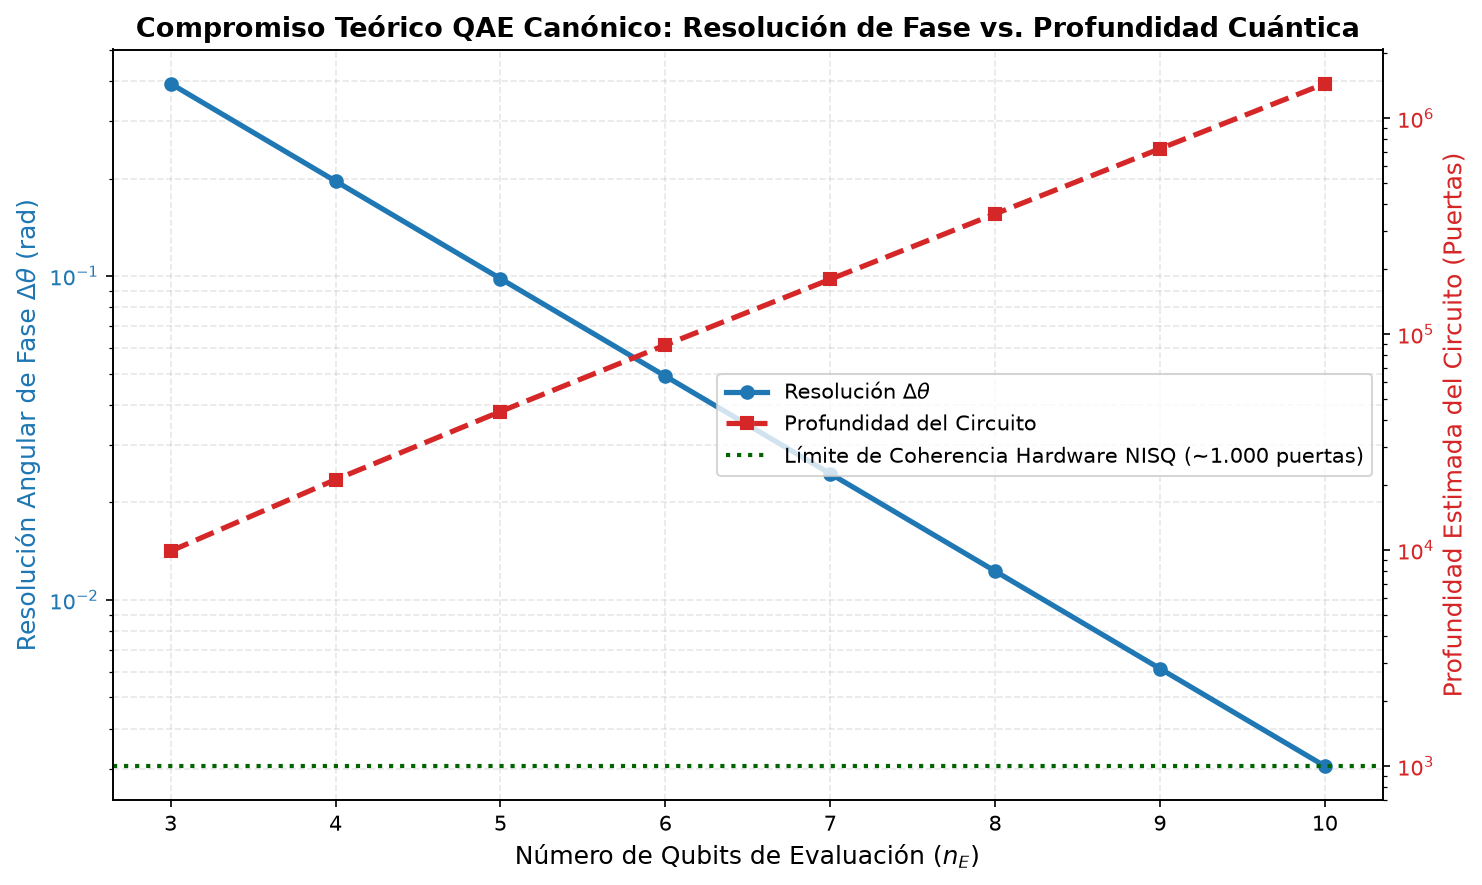

In [7]:
n_E_range = np.arange(3, 11)
angular_resolution = np.pi / (2 ** n_E_range)
grover_iterations = (2 ** n_E_range) - 1
approx_circuit_depth = grover_iterations * 1415

fig, ax1 = plt.subplots(figsize=(10, 6))

color_res = 'tab:blue'
ax1.set_xlabel('Número de Qubits de Evaluación ($n_E$)', fontsize=12)
ax1.set_ylabel(r'Resolución Angular de Fase $\Delta \theta$ (rad)', color=color_res, fontsize=12)
line1 = ax1.plot(n_E_range, angular_resolution, color=color_res, marker='o', lw=2.5, label=r'Resolución $\Delta \theta$')
ax1.tick_params(axis='y', labelcolor=color_res)
ax1.set_yscale('log')
ax1.grid(True, which="both", ls="--", alpha=0.3)

ax2 = ax1.twinx()
color_depth = 'tab:red'
ax2.set_ylabel('Profundidad Estimada del Circuito (Puertas)', color=color_depth, fontsize=12)
line2 = ax2.plot(n_E_range, approx_circuit_depth, color=color_depth, marker='s', lw=2.5, linestyle='--', label='Profundidad del Circuito')
ax2.tick_params(axis='y', labelcolor=color_depth)
ax2.set_yscale('log')

ax2.axhline(y=1000, color='darkgreen', linestyle=':', lw=2, label='Límite de Coherencia Hardware NISQ (~1.000 puertas)')

lines = line1 + line2 + [ax2.get_lines()[-1]]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', frameon=True, fontsize=10)

plt.title('Canonical QAE Theoretical Trade-off: Phase Resolution vs. Quantum Depth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(fig_results_dir, 'figura_qae_tradeoff_nisq.png'), dpi=300)
plt.show()

print(f"✓ Gráfica del trade-off NISQ guardada en '{fig_results_dir}/figura_qae_tradeoff_nisq.png'.")

## 8. Conclusions of Deliverable 02 for the Thesis Manuscript

1. **Success of the QBN-QAE Architecture:** The mathematical viability of synthesizing the K2-18b Bayesian network and coupling it to the Grover operator with phase kickback has been demonstrated in ideal simulation.
2. **Overcoming the Classical Limit:** QAE demonstrates an asymptotic quadratic convergence rate $\mathcal{O}(1/M_q)$, validating the quantum potential to estimate exoplanetary probabilities without the $\mathcal{O}(1/\sqrt{M})$ stagnation of MCMC.
3. **The Challenge of the NISQ Era:** The depth of $\sim 43,000$ gates required for $n_E = 5$ confirms that QFT-based canonical QAE is a demanding algorithm that would severely degrade on noisy physical processors. This sets the stage for **Deliverable 03 (Simulation with Noise Models)** and future research in **IQAE**.